In [1]:
from datasets import load_dataset

ds = load_dataset("Hello-SimpleAI/HC3", "medicine")

In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'human_answers', 'chatgpt_answers'],
        num_rows: 1248
    })
})


HC3 summary
    source     n  mean_entropy  median_entropy  std_entropy  mean_word_count
0  chatgpt  1248      2.925713        2.942276     0.166173       187.084135
1    human  1248      2.818547        2.850044     0.200178        82.215545

Direct comparison
             group  mean_entropy
0        HC3 human      2.818547
1      HC3 ChatGPT      2.925713
2   arXiv pre-2023      2.760238
3  arXiv post-2023      2.784973


/storage/homefs/hh25g551/.tmp/ipykernel_1682621/370399783.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


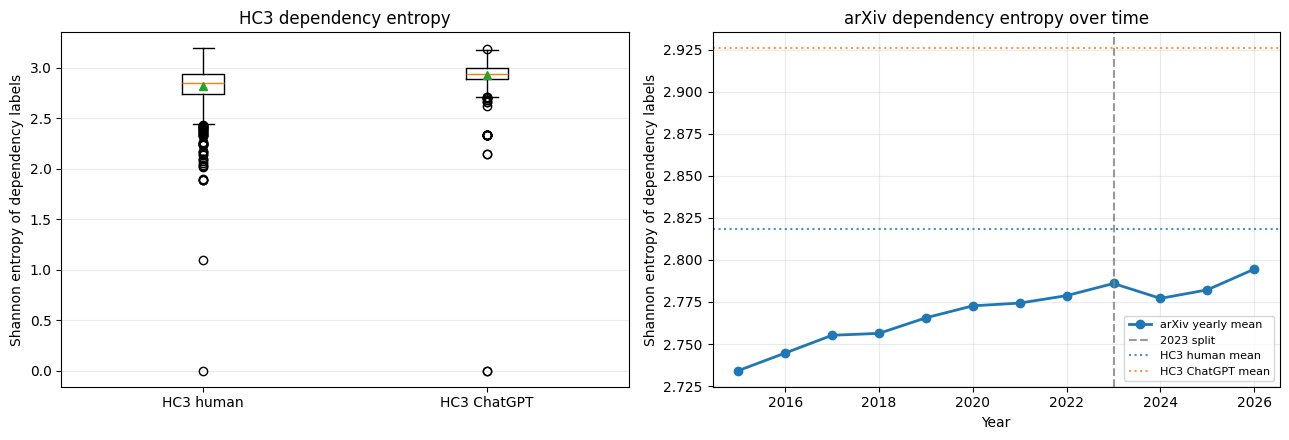


Interpretation check:
If HC3 human is closer to arXiv pre-2023 and HC3 ChatGPT is closer to post-2023, that supports the idea that the arXiv trend tracks the human-to-LLM shift.


In [3]:
from pathlib import Path
from collections import Counter
import math

import matplotlib.pyplot as plt
import pandas as pd
import spacy
from datasets import load_dataset

# Load HC3
ds = load_dataset("Hello-SimpleAI/HC3", "medicine")

# Same entropy definition used in the analysis pipeline
def dependency_entropy(text: str, nlp) -> float:
    doc = nlp(str(text))
    deps = [token.dep_ for token in doc if token.dep_ != "punct"]
    if not deps:
        return 0.0
    counts = Counter(deps)
    total = sum(counts.values())
    return -sum((count / total) * math.log(count / total) for count in counts.values())

def first_answer(values) -> str:
    return values[0] if isinstance(values, list) and values else ""

# Parse answers
nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])

rows = []
for row in ds["train"]:
    rows.append({"source": "human", "text": first_answer(row["human_answers"])})
    rows.append({"source": "chatgpt", "text": first_answer(row["chatgpt_answers"])})

hc3 = pd.DataFrame(rows)
hc3["word_count"] = hc3["text"].astype(str).str.split().str.len()
hc3["dependency_entropy"] = [dependency_entropy(text, nlp) for text in hc3["text"]]

# Summary table
summary = (
    hc3.groupby("source")
    .agg(
        n=("dependency_entropy", "size"),
        mean_entropy=("dependency_entropy", "mean"),
        median_entropy=("dependency_entropy", "median"),
        std_entropy=("dependency_entropy", "std"),
        mean_word_count=("word_count", "mean"),
    )
    .reset_index()
)
summary["std_entropy"] = summary["std_entropy"].fillna(0.0)
print("HC3 summary")
print(summary)

# Load arXiv yearly trend
arxiv_path = Path("/storage/homefs/hh25g551/ondemand/data/not-an-llm/data/analysis/arxiv_feature_trends_by_year.csv")
arxiv_yearly = pd.read_csv(arxiv_path)

arxiv_entropy = arxiv_yearly[["year", "dependency_entropy_yearly_mean"]].dropna().copy()
pre_2023 = arxiv_entropy[arxiv_entropy["year"] <= 2022]
post_2023 = arxiv_entropy[arxiv_entropy["year"] >= 2023]

comparison = pd.DataFrame(
    {
        "group": ["HC3 human", "HC3 ChatGPT", "arXiv pre-2023", "arXiv post-2023"],
        "mean_entropy": [
            hc3.loc[hc3["source"] == "human", "dependency_entropy"].mean(),
            hc3.loc[hc3["source"] == "chatgpt", "dependency_entropy"].mean(),
            pre_2023["dependency_entropy_yearly_mean"].mean(),
            post_2023["dependency_entropy_yearly_mean"].mean(),
        ],
    }
)
print("\nDirect comparison")
print(comparison)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].boxplot(
    [
        hc3.loc[hc3["source"] == "human", "dependency_entropy"],
        hc3.loc[hc3["source"] == "chatgpt", "dependency_entropy"],
    ],
    labels=["HC3 human", "HC3 ChatGPT"],
    showmeans=True,
)
axes[0].set_title("HC3 dependency entropy")
axes[0].set_ylabel("Shannon entropy of dependency labels")
axes[0].grid(alpha=0.25, axis="y")

axes[1].plot(
    arxiv_entropy["year"],
    arxiv_entropy["dependency_entropy_yearly_mean"],
    marker="o",
    linewidth=2,
    label="arXiv yearly mean",
)
axes[1].axvline(2023, linestyle="--", color="gray", alpha=0.8, label="2023 split")
axes[1].axhline(
    comparison.loc[comparison["group"] == "HC3 human", "mean_entropy"].iloc[0],
    linestyle=":",
    color="tab:blue",
    alpha=0.8,
    label="HC3 human mean",
)
axes[1].axhline(
    comparison.loc[comparison["group"] == "HC3 ChatGPT", "mean_entropy"].iloc[0],
    linestyle=":",
    color="tab:orange",
    alpha=0.8,
    label="HC3 ChatGPT mean",
)
axes[1].set_title("arXiv dependency entropy over time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Shannon entropy of dependency labels")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nInterpretation check:")
print(
    "If HC3 human is closer to arXiv pre-2023 and HC3 ChatGPT is closer to post-2023, "
    "that supports the idea that the arXiv trend tracks the human-to-LLM shift."
)